In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils

# The second run for test
THe first run was using TATT model for 2pt.
Now we use NLA model consistently to see the improvement in the IA parameter constraint.

In [3]:
def get(fname):
    chain, params, labels = utils.read_des_chain(fname, take=['om', 's8', 'sig8', 'a1', 'a2', 'alpha1', 'alpha2'])
    samples = utils.to_mcsamples(chain, params, labels)
    # utils.wplot(chain, params, labels)
    return samples

In [4]:
samples_2pt_map3_auto_334_344 = get('../output/test-second-run/des-y3-2pt-map3-addcross334-344.txt')
samples_2pt_map3_auto = get('../output/test-second-run/des-y3-2pt-map3.txt')
samples_2pt = get('../output/test-second-run/des-y3-2pt.txt')

['om', 's8', 'm1', 'm2', 'm3', 'm4', 'a1', 'alpha1', 'sig8', '2pt-chi2', 'prior', 'like', 'post', 'weight']
Removed no burn in
['om', 's8', 'm1', 'm2', 'm3', 'm4', 'a1', 'alpha1', 'sig8', '2pt-chi2', 'prior', 'like', 'post', 'weight']
Removed no burn in
['om', 's8', 'm1', 'm2', 'm3', 'm4', 'a1', 'alpha1', 'sig8', '2pt-chi2', 'prior', 'like', 'post', 'weight']
Removed no burn in


<Figure size 1000x1000 with 0 Axes>

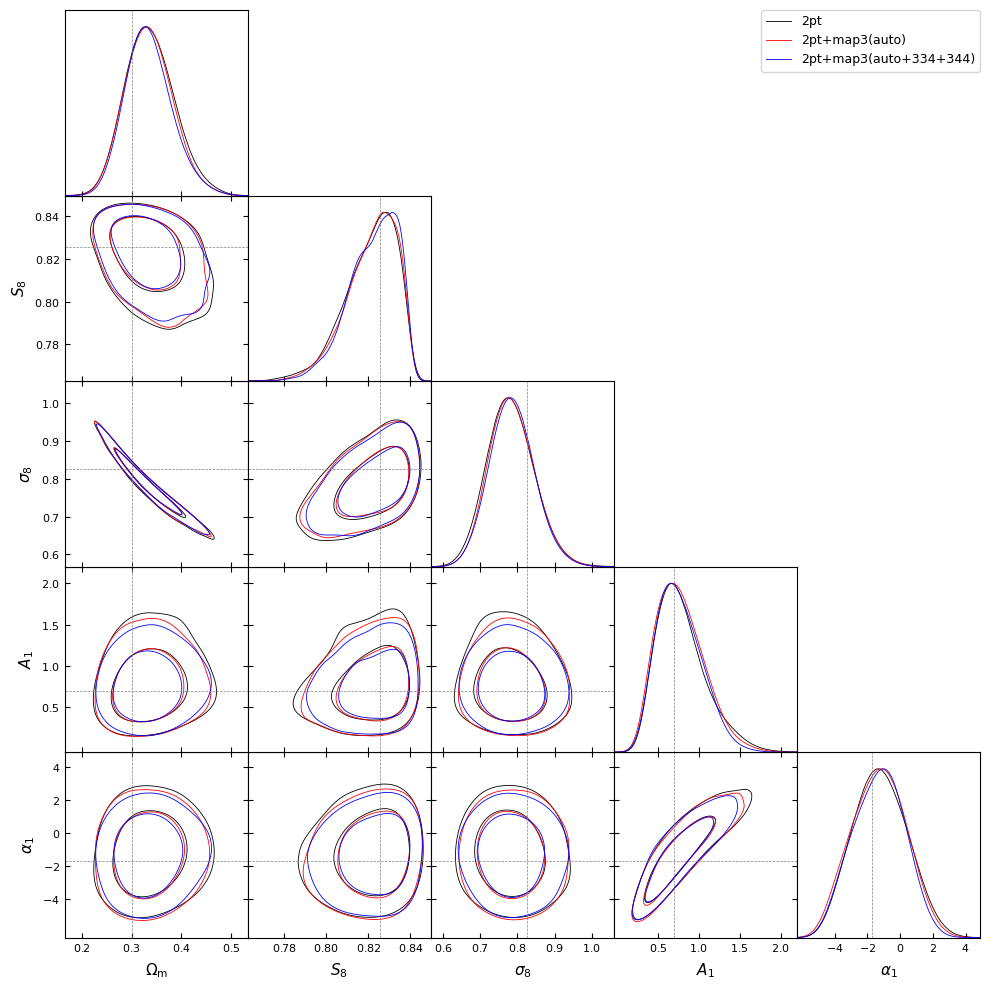

In [5]:
g = plots.get_single_plotter(ratio=1, width_inch=10)
g.triangle_plot([samples_2pt, samples_2pt_map3_auto, samples_2pt_map3_auto_334_344], ['om', 's8', 'sig8', 'a1', 'alpha1'], filled=False, \
    legend_labels=['2pt', '2pt+map3(auto)', '2pt+map3(auto+334+344)'], legend_loc='upper right', 
    markers={'om': 0.3, 's8': 0.8256, 'sig8': 0.8256, 'a1':0.7, 'alpha1':-1.7})
plt.show()

In [6]:
names = ['s8', 'om']
samples_list = [samples_2pt, samples_2pt_map3_auto, samples_2pt_map3_auto_334_344]
fom = np.array([utils.FoM_from_samples_names(s, names) for s in samples_list])
improve = fom/fom[0]

In [7]:
fom

array([1716.39628387, 1862.55435467, 1957.88000375])

In [8]:
improve

array([1.        , 1.08515404, 1.14069229])

In [9]:
import threepoint

4.309730887353826


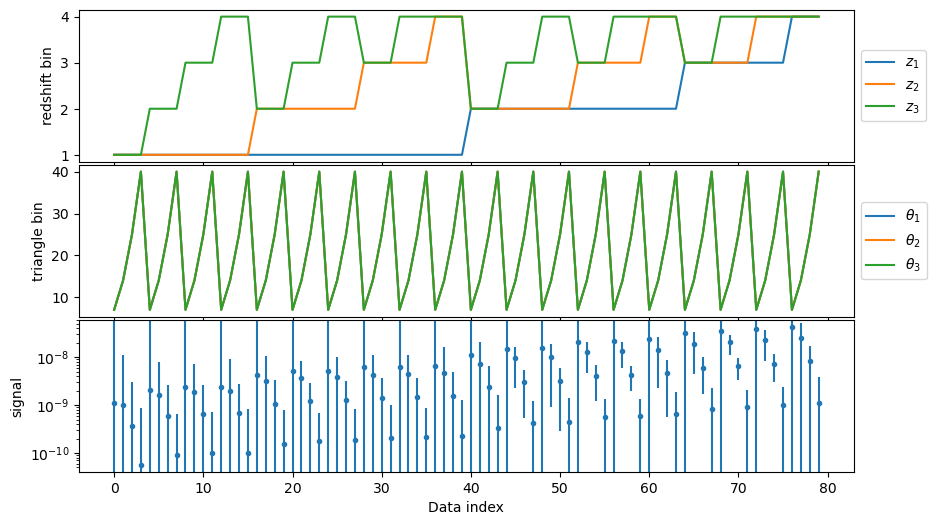

In [12]:
thpt = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA.fits')
print(thpt.get_snr())
fig = thpt.plot(yscale='log', nt=1)

In [13]:
thpt.reduce_by_z_bin_selection(['auto', '3,3,4', '3,4,4'])

3.036130236705171


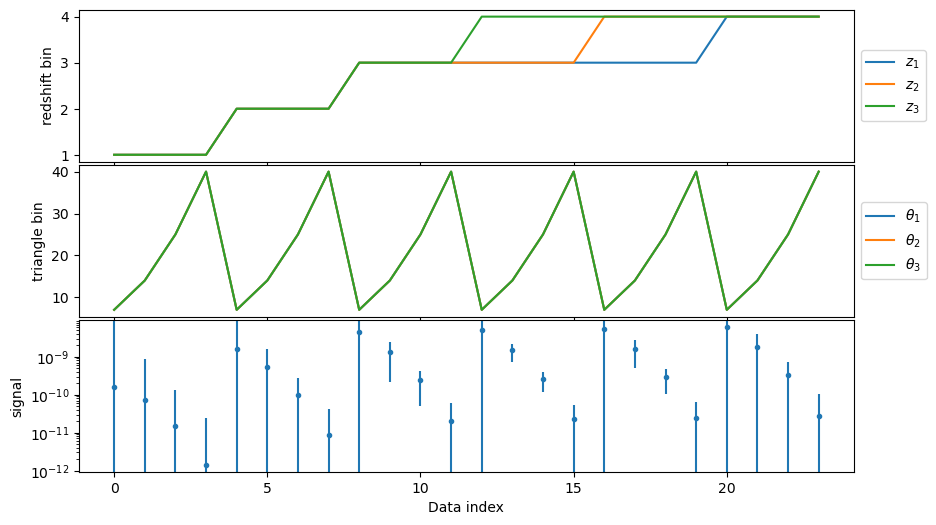

In [17]:
print(thpt.get_snr())
fig = thpt.plot(yscale='log')

In [ ]:
np.diag(thpt.get_covariance())**0.5

array([2.08002748e-08, 7.35694326e-10, 1.07848784e-10, 2.09868634e-11,
       2.54475210e-08, 1.02369879e-09, 1.70678387e-10, 3.22581253e-11,
       2.75908555e-08, 1.06080522e-09, 1.76563603e-10, 3.66078845e-11,
       1.91759036e-08, 6.74676250e-10, 1.35824536e-10, 2.88920741e-11,
       2.76273582e-08, 1.05280716e-09, 1.76157787e-10, 3.58610264e-11,
       5.52456457e-08, 2.01721193e-09, 3.62431229e-10, 7.30469459e-11])

In [ ]:
thpt.get_t_bin()[0,:]

array([ 7., 14., 25., 40.,  7., 14., 25., 40.,  7., 14., 25., 40.,  7.,
       14., 25., 40.,  7., 14., 25., 40.,  7., 14., 25., 40.])